In [1]:
import numpy as np
import os

era5_path = "/home/teoaivalis/floods_kg/reanalysis_data/era5_cnn_256_baseline.npy"
pangu_path = "/home/teoaivalis/floods_kg/reanalysis_data/pangu_cnn_256_baseline.npy"
graphcast_path = "/home/teoaivalis/floods_kg/reanalysis_data/graphcast_cnn_256_baseline.npy"

# Load the dictionaries
era5_data = np.load(era5_path, allow_pickle=True).item()
pangu_data = np.load(pangu_path, allow_pickle=True).item()
graphcast_data = np.load(graphcast_path, allow_pickle=True).item()

In [75]:
datasets = {
    "ERA5 (Truth)": era5_data,
    "Pangu (Pred)": pangu_data,
    "GraphCast (Pred)": graphcast_data
}

for name, data in datasets.items():
    num_events = len(data)
    # Get the first key to check the vector shape
    first_key = list(data.keys())[0]
    vector_shape = data[first_key].shape
    
    print(f"--- {name} ---")
    print(f"Total Flood Events: {num_events}")
    print(f"Embedding Dimension: {vector_shape}")
    print(f"Sample Event ID: {first_key}\n")

--- ERA5 (Truth) ---
Total Flood Events: 1242
Embedding Dimension: (256,)
Sample Event ID: FL_2005_000166_CRI

--- Pangu (Pred) ---
Total Flood Events: 237
Embedding Dimension: (256,)
Sample Event ID: FL_2019_000052_SRB

--- GraphCast (Pred) ---
Total Flood Events: 57
Embedding Dimension: (256,)
Sample Event ID: FF_2020_000138_TJK



In [ ]:
def print_dict_head(data, n=3):
    keys = list(data.keys())[:n]
    for i, key in enumerate(keys):
        #first 5 values of the vector
        vector_sample = data[key][:5] 
        print(f"{i+1}. Event ID: {key}")
        print(f"   Vector Slice (first 5 dims): {vector_sample}...")
    print("-" * 30)

print("🔍 ERA5 Head:")
print_dict_head(era5_data)

print("🔍 Pangu Head:")
print_dict_head(pangu_data)

print("🔍 GraphCast Head:")
print_dict_head(graphcast_data)

🔍 ERA5 Head:
1. Event ID: FL_2005_000166_CRI
   Vector Slice (first 5 dims): [ 0.01522598  0.01341265 -0.00875361 -0.02792024  0.00343392]...
2. Event ID: FL_2008_000079_LKA
   Vector Slice (first 5 dims): [-0.00224797  0.03064475 -0.02546681 -0.04415429  0.02413412]...
3. Event ID: FL_2016_000011_TZA
   Vector Slice (first 5 dims): [-0.01288355  0.02577741 -0.02684967 -0.03622186  0.02077765]...
------------------------------
🔍 Pangu Head:
1. Event ID: FL_2019_000052_SRB
   Vector Slice (first 5 dims): [-0.00819279 -0.03546514 -0.00657472 -0.02608908  0.05680956]...
2. Event ID: FF_2022_000278_MNG
   Vector Slice (first 5 dims): [-0.01500451 -0.03757239  0.01989114 -0.01141523  0.06122709]...
3. Event ID: FL_2019_000153_COD
   Vector Slice (first 5 dims): [-0.01206528 -0.02785119 -0.00819134 -0.02595063  0.06404263]...
------------------------------
🔍 GraphCast Head:
1. Event ID: FF_2020_000138_TJK
   Vector Slice (first 5 dims): [-0.03113903  0.01702281 -0.03962862 -0.02266541 -0.022

In [87]:
import torch
import numpy as np
import torch.nn.functional as F

def check_embedding_stats(name, data_dict):
    # Convert dict values to a single tensor [N, 1024]
    embeddings = torch.tensor(np.array(list(data_dict.values())))
    
    # 1. Variance per dimension (Average variance across the 1024 dims)
    var = torch.var(embeddings, dim=0).mean().item()
    
    # 2. L2 Norm (Are they exploded or vanished?)
    norms = torch.norm(embeddings, p=2, dim=1).mean().item()
    
    # 3. Cosine Similarity Matrix (Internal Consistency)
    sample_size = min(500, embeddings.shape[0])
    sample = embeddings[:sample_size]
    sample_norm = F.normalize(sample, p=2, dim=1)
    cos_sim = torch.mm(sample_norm, sample_norm.t())
    
    # Average similarity between different events
    avg_sim = (cos_sim.sum() - sample_size) / (sample_size * (sample_size - 1))

    print(f"--- Statistics for {name} ---")
    print(f"Mean Variance: {var:.6f}")
    print(f"Average L2 Norm: {norms:.2f}")
    print(f"Avg Internal Cosine Similarity: {avg_sim:.4f}")

check_embedding_stats("ERA5", era5_data)
check_embedding_stats("Pangu", pangu_data)
check_embedding_stats("GraphCast", graphcast_data)

--- Statistics for ERA5 ---
Mean Variance: 0.000079
Average L2 Norm: 0.55
Avg Internal Cosine Similarity: 0.9359
--- Statistics for Pangu ---
Mean Variance: 0.000081
Average L2 Norm: 0.55
Avg Internal Cosine Similarity: 0.9327
--- Statistics for GraphCast ---
Mean Variance: 0.000091
Average L2 Norm: 0.60
Avg Internal Cosine Similarity: 0.9374


In [86]:
import torch
import torch.nn.functional as F
import numpy as np


era5_emb = np.load("/home/teoaivalis/floods_kg/reanalysis_data/era5_cnn_256_baseline.npy", allow_pickle=True).item()
pangu_emb = np.load("/home/teoaivalis/floods_kg/reanalysis_data/pangu_cnn_256_baseline.npy", allow_pickle=True).item()
gc_emb = np.load("/home/teoaivalis/floods_kg/reanalysis_data/graphcast_cnn_256_baseline.npy", allow_pickle=True).item()

def find_top_n_era5_matches(query_id, pangu_dict, era5_dict, n=5):
    if query_id not in pangu_dict:
        print(f"Error: ID {query_id} not found in Pangu embeddings.")
        return

    # Convert query to tensor
    query_vec = torch.tensor(pangu_dict[query_id]).float().unsqueeze(0) # [1, 1024]
    
    # Prepare ERA5 pool
    era5_keys = list(era5_dict.keys())
    era5_matrix = torch.tensor(np.array([era5_dict[k] for k in era5_keys])).float() # [N, 1024]
    
    # Calculate Cosine Similarity
    query_norm = F.normalize(query_vec, p=2, dim=1)
    era5_norm = F.normalize(era5_matrix, p=2, dim=1)
    
    # Matrix multiplication to get all similarities
    similarities = torch.mm(query_norm, era5_norm.t()).squeeze(0) # [N]
    
    # Get top N indices
    top_values, top_indices = torch.topk(similarities, k=n)
    
    print(f"Query (Pangu Source): {query_id}")
    print(f"--- Top {n} Most Similar Events in ERA5 (Ground Truth Source) ---")
    
    for i in range(n):
        match_id = era5_keys[top_indices[i]]
        score = top_values[i].item()
        
        # Check if it found itself
        print(f"{i+1}. {match_id} | Similarity: {score:.6f}")

print ("Pangu Predictions")
find_top_n_era5_matches("FL_2018_000425_LKA", pangu_emb, era5_emb)
find_top_n_era5_matches("FL_2020_000128_KEN", pangu_emb, era5_emb)
find_top_n_era5_matches("FL_2021_000161_IND", pangu_emb, era5_emb)
find_top_n_era5_matches("FL_2022_000201_ZAF", pangu_emb, era5_emb)

print ("GraphCast Predictions")
find_top_n_era5_matches("FL_2019_000162_MYS", pangu_emb, gc_emb)
find_top_n_era5_matches("FL_2020_000128_KEN", pangu_emb, gc_emb)
find_top_n_era5_matches("FL_2020_000161_BGD", pangu_emb, gc_emb)
find_top_n_era5_matches("FL_2020_000172_MMR", pangu_emb, gc_emb)


Pangu Predictions
Query (Pangu Source): FL_2018_000425_LKA
--- Top 5 Most Similar Events in ERA5 (Ground Truth Source) ---
1. FL_2012_000005_BOL | Similarity: 0.119665
2. FL_2011_000091_BEN | Similarity: 0.113524
3. FL_2018_000015_BOL | Similarity: 0.113013
4. FL_2018_000425_LKA | Similarity: 0.111783
5. FL_2000_000583_LAO | Similarity: 0.109739
Query (Pangu Source): FL_2020_000128_KEN
--- Top 5 Most Similar Events in ERA5 (Ground Truth Source) ---
1. FL_2012_000005_BOL | Similarity: 0.156463
2. FL_2018_000015_BOL | Similarity: 0.152147
3. FL_2011_000091_BEN | Similarity: 0.151171
4. FL_2021_000066_GUY | Similarity: 0.148479
5. FL_2009_000135_MEX | Similarity: 0.142038
Query (Pangu Source): FL_2021_000161_IND
--- Top 5 Most Similar Events in ERA5 (Ground Truth Source) ---
1. FL_2018_000015_BOL | Similarity: 0.124793
2. FL_2012_000005_BOL | Similarity: 0.124550
3. FL_2021_000066_GUY | Similarity: 0.123667
4. FL_2011_000091_BEN | Similarity: 0.120111
5. FL_2009_000135_MEX | Similarity: 0

visualise for the paper

In [5]:
!pip install cartopy xarray scipy netCDF4 geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 9.3 MB/s  0:00:01m0:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 58.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 34.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [cartopy]m3/4 [cartopy]


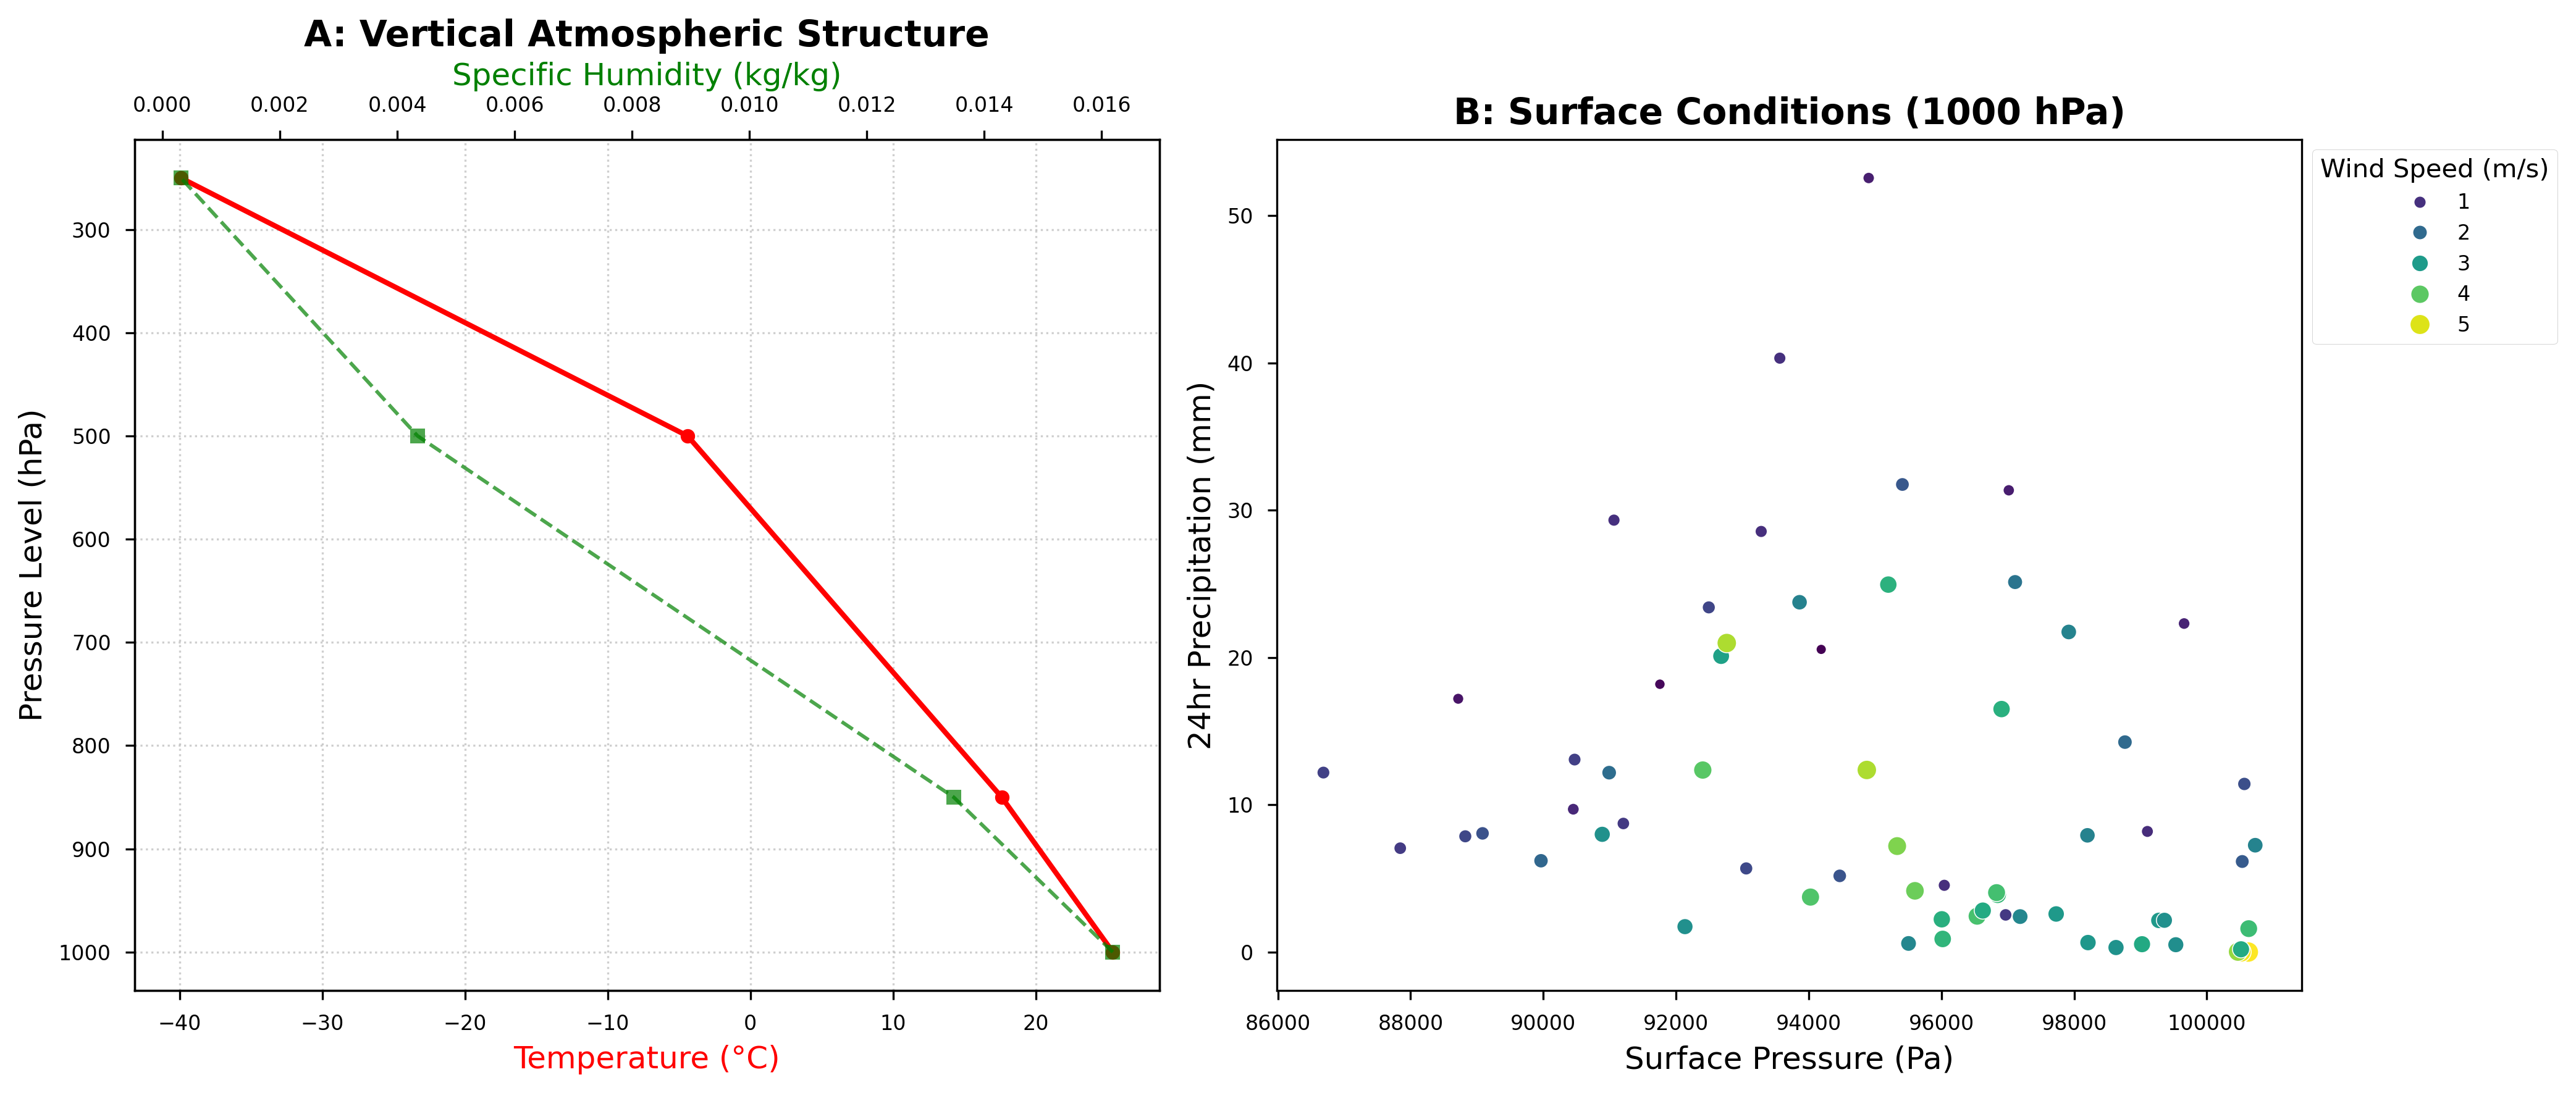

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the data
file_path = "/home/teoaivalis/floods_kg/reanalysis_data/era5_ground_truth/FF_2004_000060_VNM/center_ERA5_truth.csv"
df = pd.read_csv(file_path)

# Convert Temperature from Kelvin to Celsius for the paper
df['temp_c'] = df['temperature'] - 273.15
df['temp_2m_c'] = df['2m_temperature'] - 273.15

# Set academic plot style
plt.style.use('seaborn-v0_8-paper')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

# --- PANEL A: VERTICAL PROFILE (Atmospheric Sounding) ---
# We take the average across the center coordinates to get the local vertical structure
v_profile = df.groupby('level')[['temp_c', 'specific_humidity', 'wind_speed']].mean().reset_index()
v_profile = v_profile.sort_values('level', ascending=False) # 1000hPa at bottom

ax1.plot(v_profile['temp_c'], v_profile['level'], 'r-o', label='Temp (°C)', linewidth=2)
ax1_twin = ax1.twiny()
ax1_twin.plot(v_profile['specific_humidity'], v_profile['level'], 'g--s', label='Spec. Humidity', alpha=0.7)

ax1.set_ylabel('Pressure Level (hPa)', fontsize=12)
ax1.set_xlabel('Temperature (°C)', color='r', fontsize=12)
ax1_twin.set_xlabel('Specific Humidity (kg/kg)', color='g', fontsize=12)
ax1.invert_yaxis() # Standard meteorological pressure plot
ax1.set_title('A: Vertical Atmospheric Structure', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- PANEL B: SURFACE FORCING (Pressure vs Precipitation) ---
# Correlation between Surface Pressure and 24h Precipitation across the grid
sns.scatterplot(data=df[df['level'] == 1000], x='surface_pressure', y='precipitation_mm_24h', 
                hue='10m_wind_speed', size='10m_wind_speed', palette='viridis', ax=ax2)

ax2.set_title('B: Surface Conditions (1000 hPa)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Surface Pressure (Pa)', fontsize=12)
ax2.set_ylabel('24hr Precipitation (mm)', fontsize=12)
ax2.legend(title='Wind Speed (m/s)', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('era5_ff_vnm_analysis.png')
plt.show()

/home/teoaivalis/.conda/envs/prithvi_env/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/teoaivalis/.conda/envs/prithvi_env/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


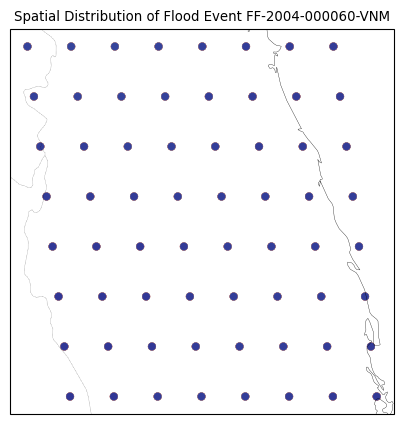

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import pandas as pd

# 1. Setup the Map with a specific projection
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.Robinson()) # Academic favorite projection

# 2. Add high-quality features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# 3. Plot your data (using the PlateCarree transform for lat/lon coordinates)
plt.scatter(df['longitude'], df['latitude'], c=df['temp_c'], 
            transform=ccrs.PlateCarree(), cmap='RdYlBu_r')

plt.title("Spatial Distribution of Flood Event FF-2004-000060-VNM")
plt.show()

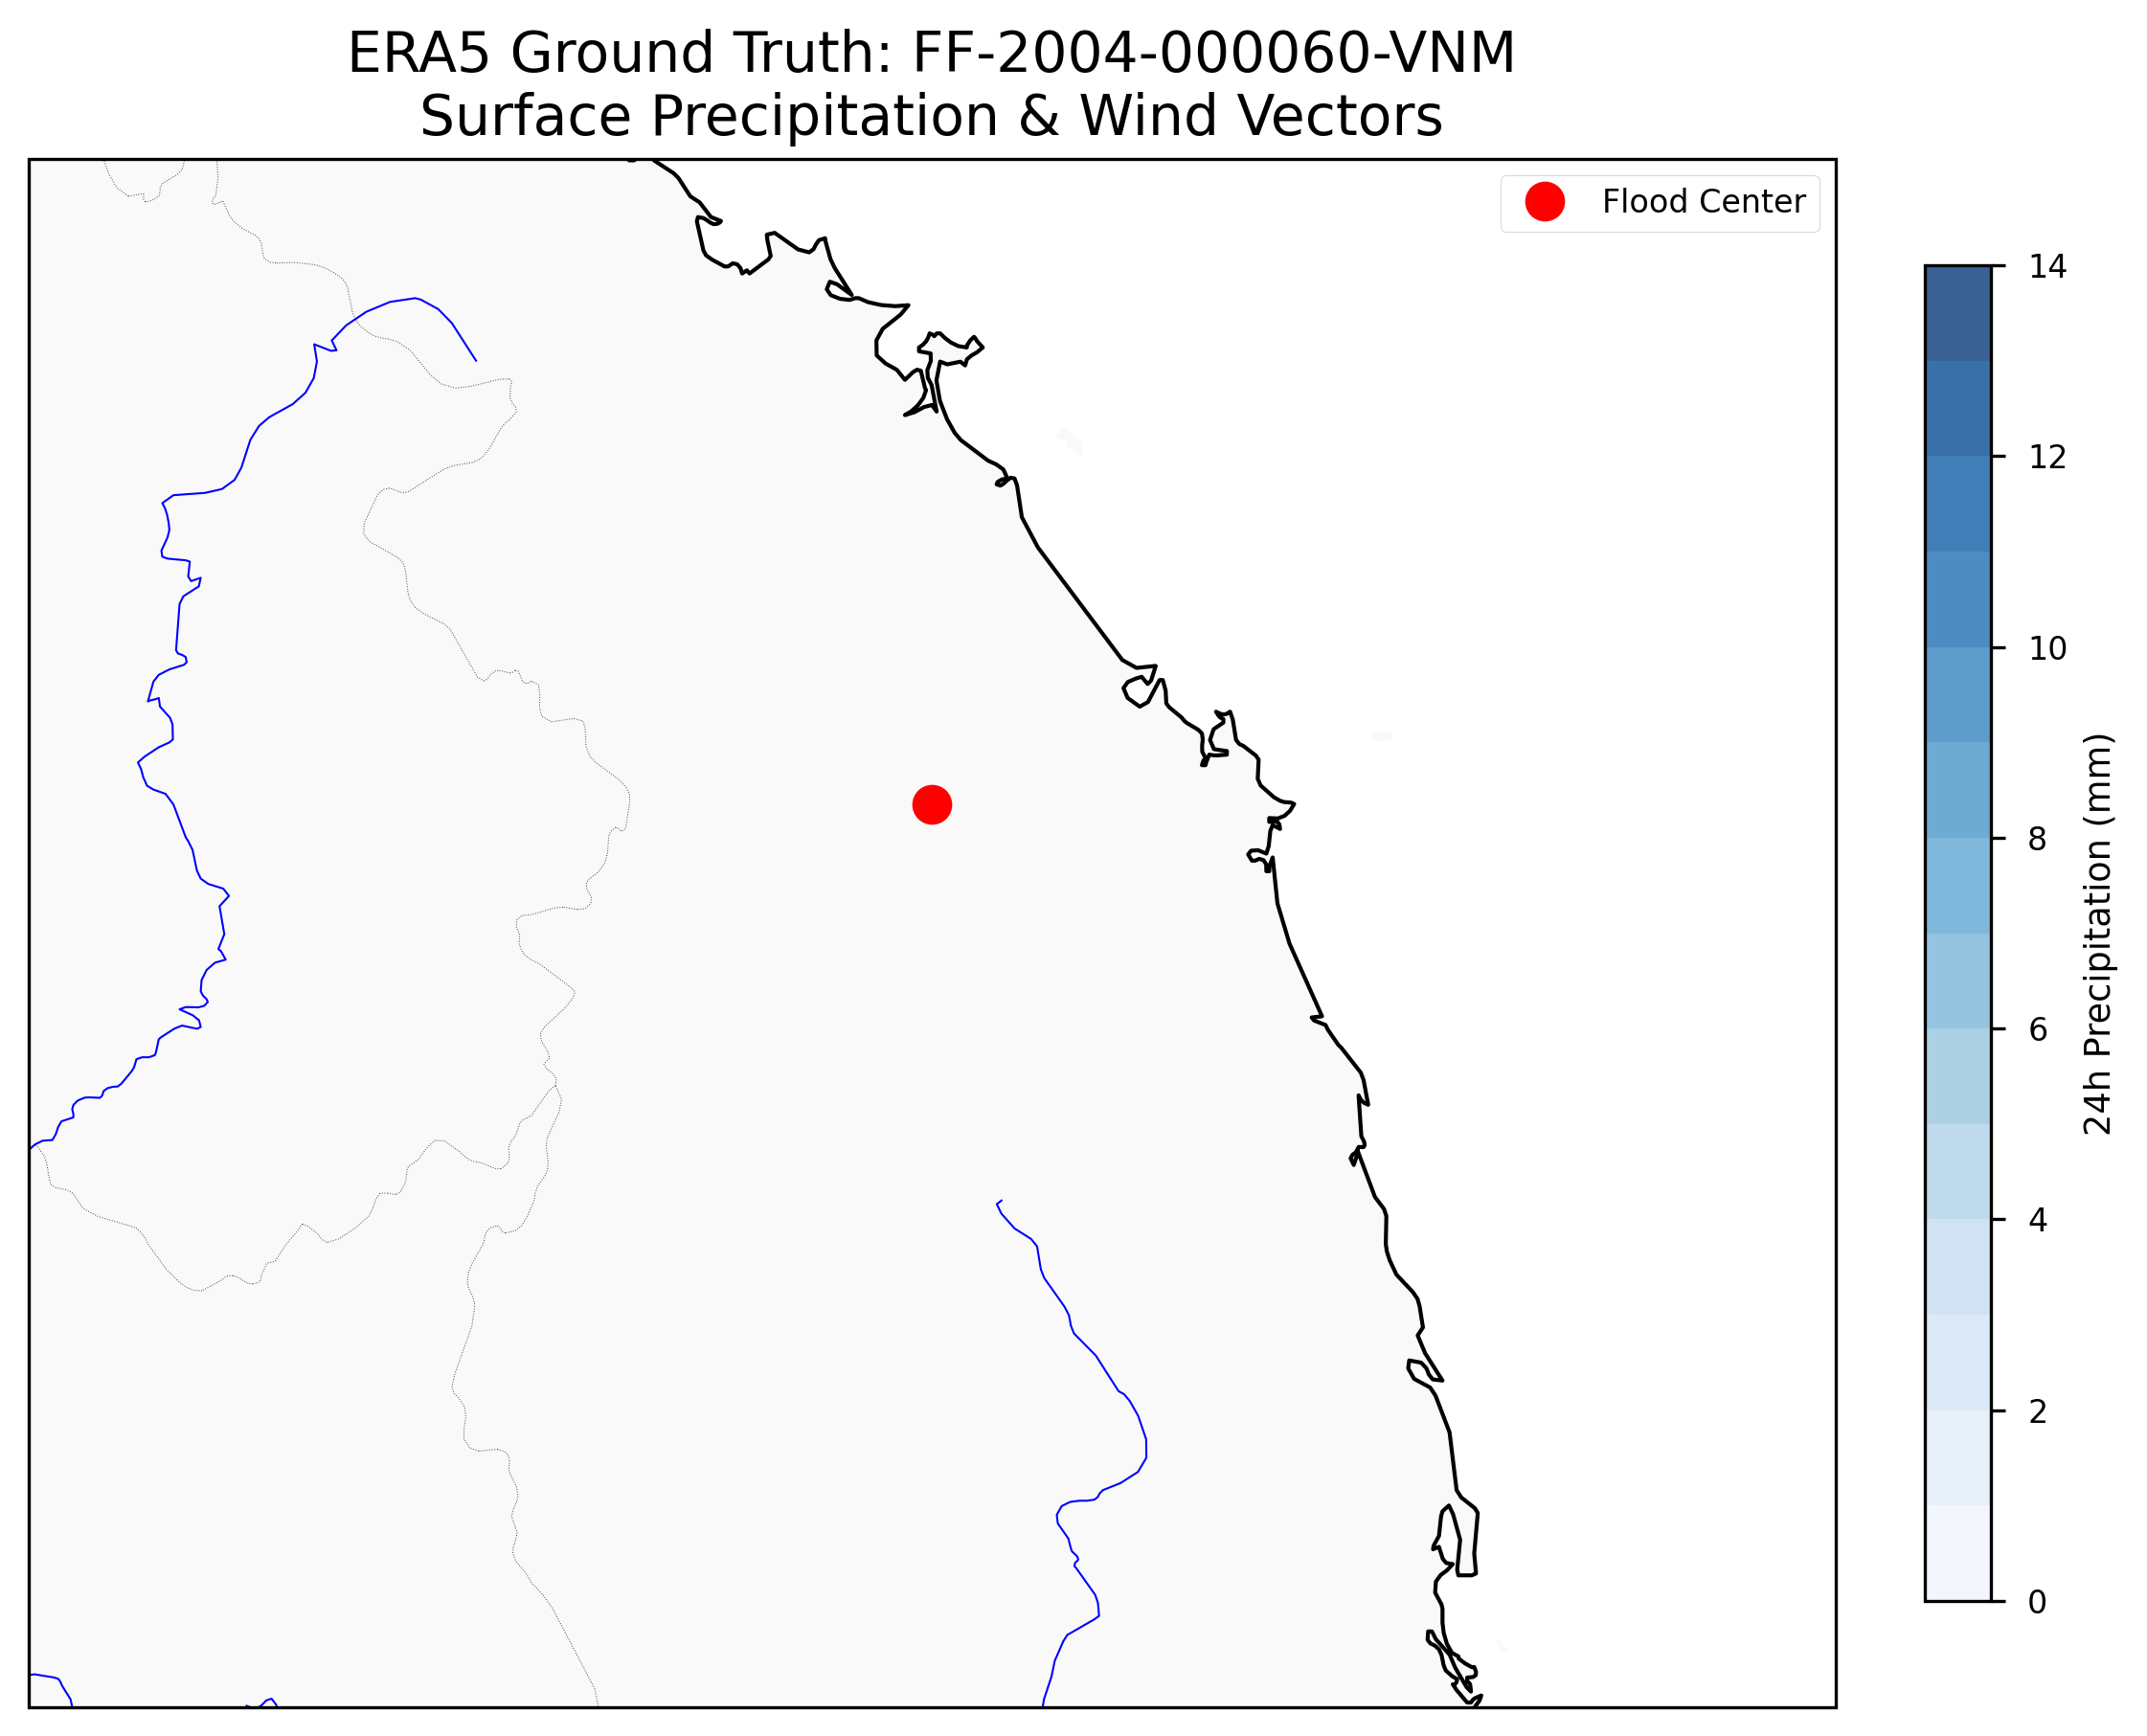

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Load your ERA5 Truth Data
file_path = "/home/teoaivalis/floods_kg/reanalysis_data/era5_ground_truth/FF_2012_000081_ETH/center_ERA5_truth.csv"
df = pd.read_csv(file_path)

# 2. Filter for surface level (1000 hPa) for the map
df_surface = df[df['level'] == 1000].copy()

# 3. Setup Plot with Cartopy Projection
fig, ax = plt.subplots(1, 1, figsize=(10, 7), dpi=300, 
                       subplot_kw={'projection': ccrs.PlateCarree()})

# Add Geographic Context
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.7)
ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue')
ax.add_feature(cfeature.LAND, facecolor='#f9f9f9')

# 4. Plot Precipitation as a filled contour (The "Heatmap")
# We use tricontourf because CSV data points are often a list of coordinates
precip_plot = ax.tricontourf(
    df_surface['longitude'], df_surface['latitude'], 
    df_surface['precipitation_mm_24h'],
    transform=ccrs.PlateCarree(),
    cmap='Blues', 
    levels=15, # Smoothness of the color gradients
    alpha=0.8
)

# Add Colorbar
plt.colorbar(precip_plot, ax=ax, label='24h Precipitation (mm)', fraction=0.03, pad=0.04)

# 5. Add Wind Vectors (Quivers) to show storm movement
ax.quiver(
    df_surface['longitude'].values, df_surface['latitude'].values,
    df_surface['u_component_of_wind'].values, df_surface['v_component_of_wind'].values,
    transform=ccrs.PlateCarree(),
    color='black', alpha=0.5, scale=40, width=0.004
)

# 6. Mark the Event Center
# Vietnam event center for FF-2004-000060
ax.plot(108.25, 15.25, 'ro', markersize=10, 
        transform=ccrs.PlateCarree(), label='Flood Center', markeredgecolor='white')

# Zoom into the relevant Vietnam region
ax.set_extent([106.5, 110.0, 13.5, 16.5], crs=ccrs.PlateCarree())

plt.title("ERA5 Ground Truth: FF-2004-000060-VNM\nSurface Precipitation & Wind Vectors", fontsize=14)
plt.legend(loc='upper right')

plt.savefig('vietnam_flood_map.png', bbox_inches='tight')
plt.show()

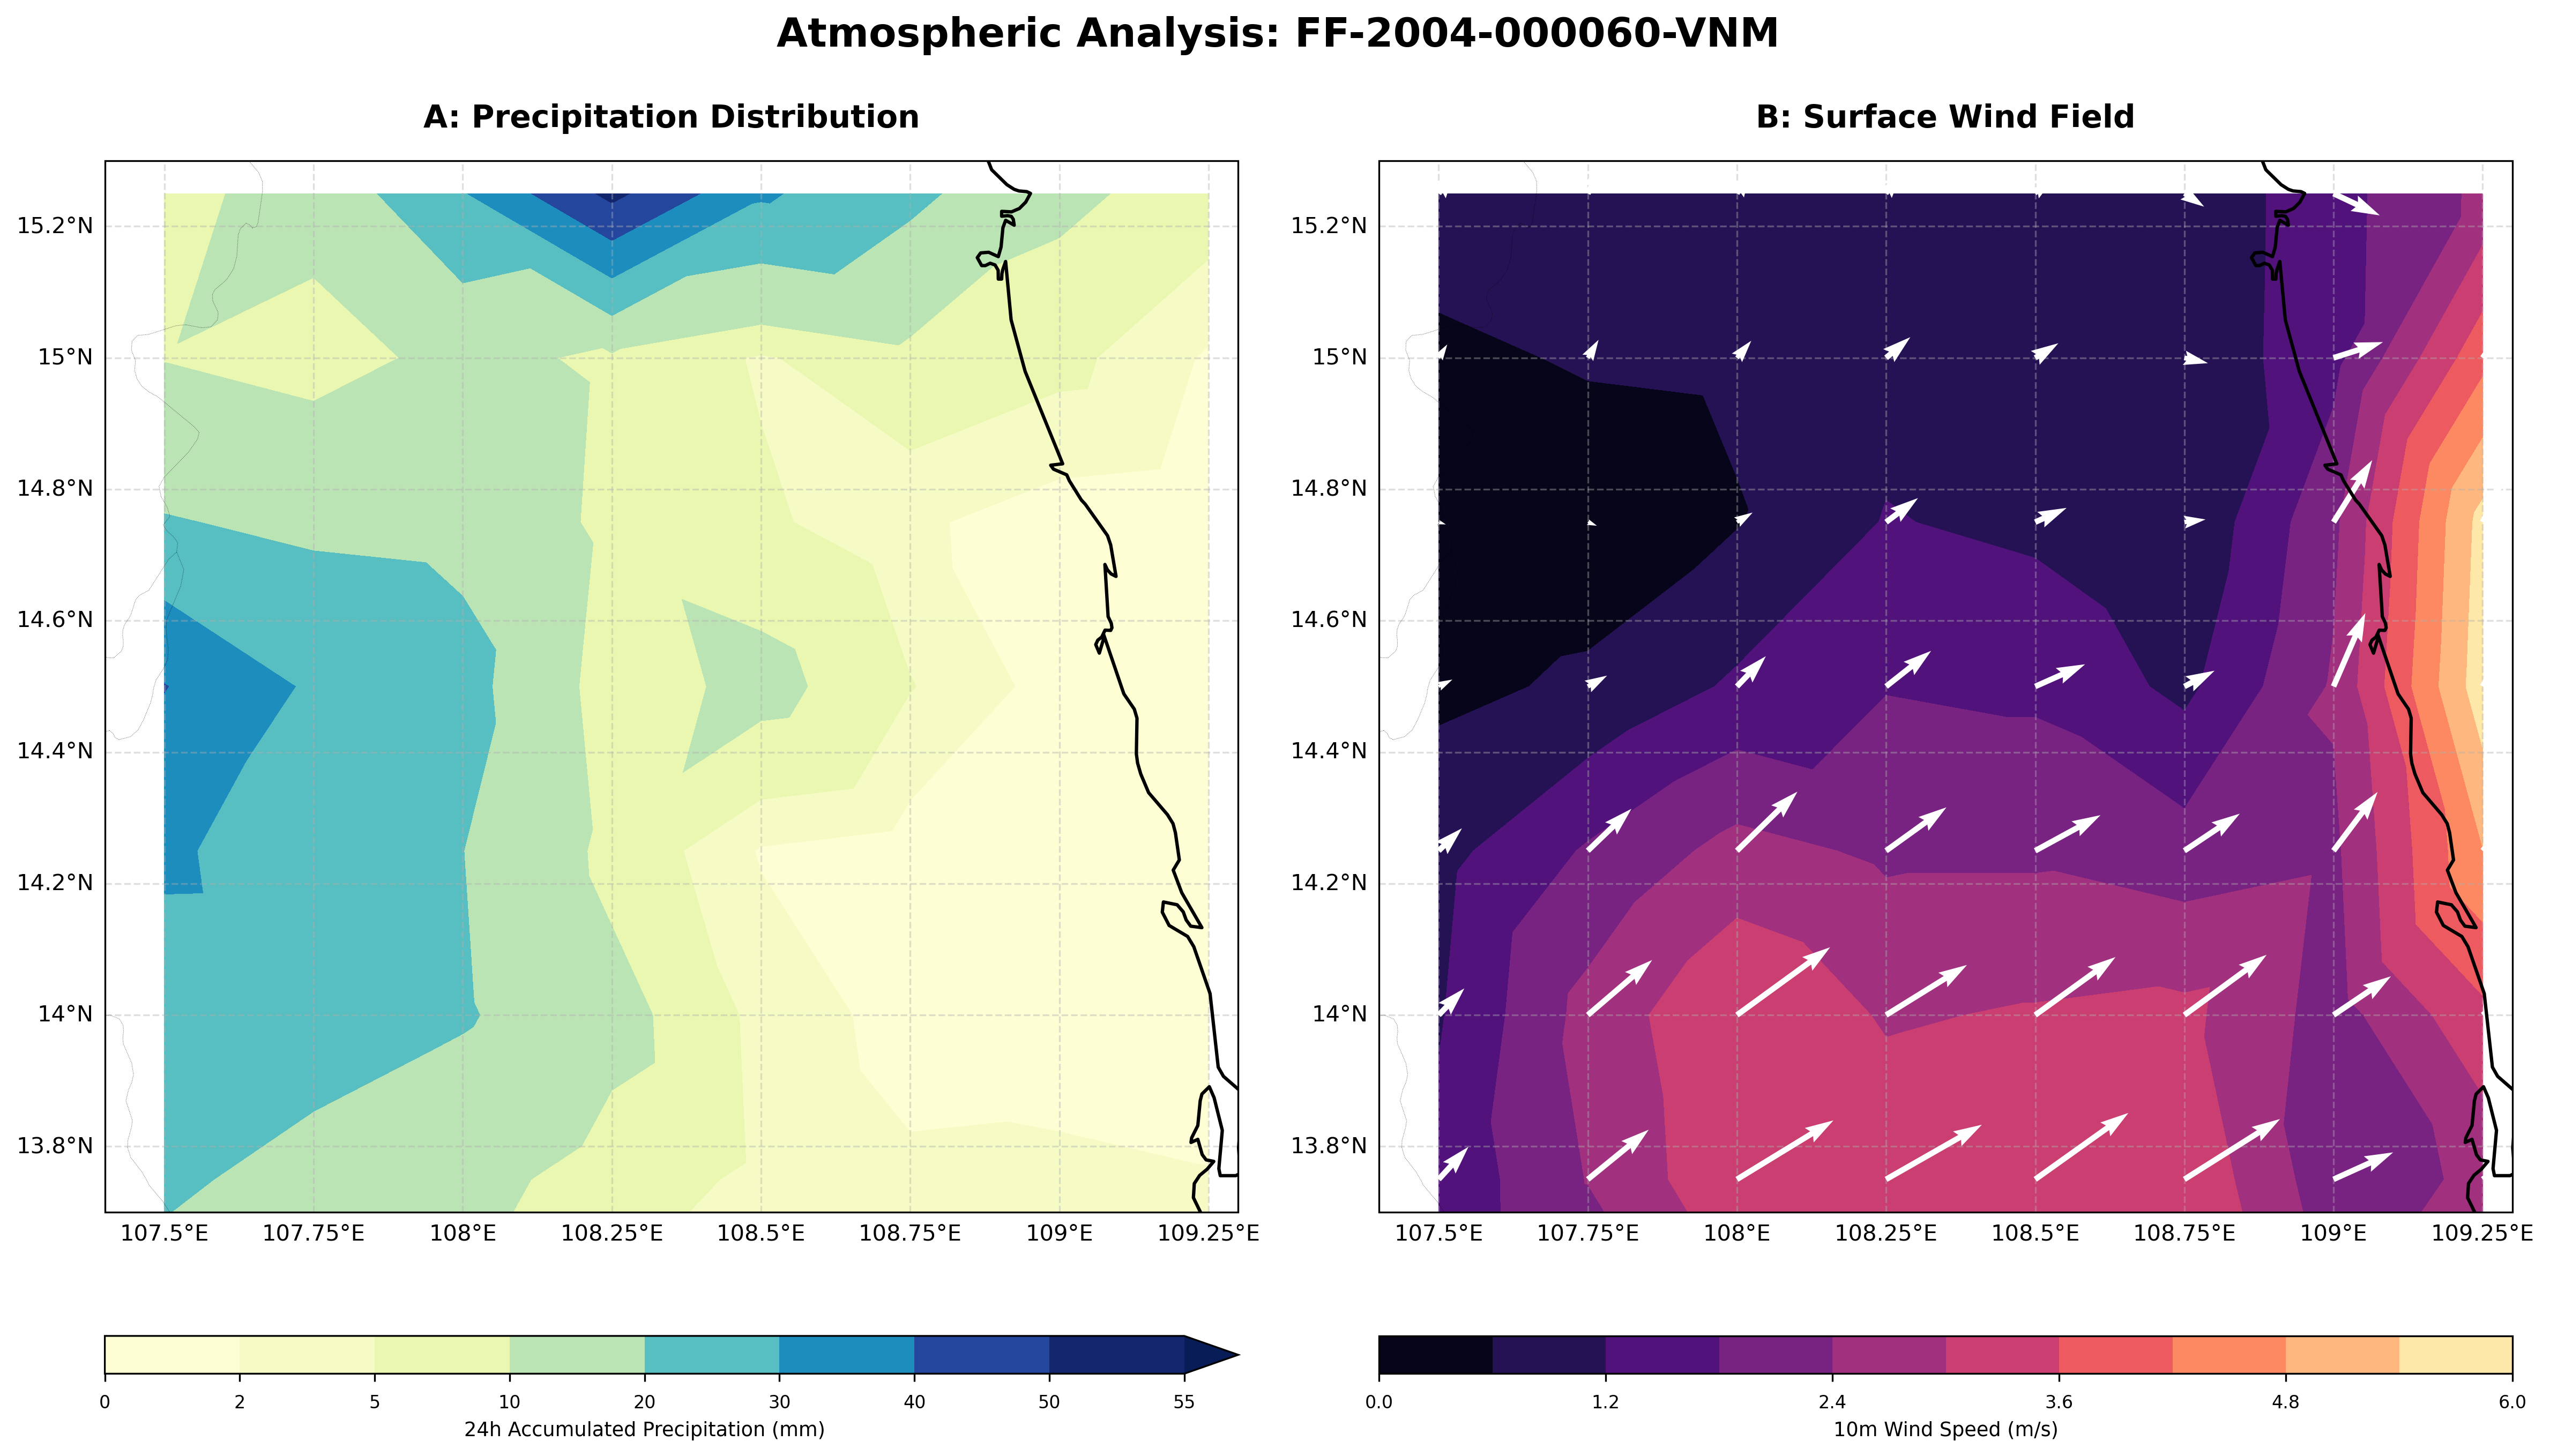

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import numpy as np

# 1. Load Data
file_path = "/home/teoaivalis/floods_kg/reanalysis_data/era5_ground_truth/FF_2004_000060_VNM/center_ERA5_truth.csv"
df = pd.read_csv(file_path)
df_surface = df[df['level'] == 1000].copy()

# 2. Setup Figure - Adjusting figsize to be wider for two panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9), dpi=300, 
                               subplot_kw={'projection': ccrs.PlateCarree()})

# Define a tight bounding box based on your data points
extent = [107.4, 109.3, 13.7, 15.3]

def format_map(ax, title):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=1.5, zorder=3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.7, zorder=3)
    ax.set_aspect('auto') # THIS FIXES THE DIMENSIONS
    
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4, zorder=4)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)

# --- Panel A: Precipitation ---
format_map(ax1, 'A: Precipitation Distribution')
precip_levels = [0, 2, 5, 10, 20, 30, 40, 50, 55]
cf1 = ax1.tricontourf(df_surface['longitude'], df_surface['latitude'], 
                      df_surface['precipitation_mm_24h'],
                      levels=precip_levels, cmap='YlGnBu', extend='max', zorder=1)

# Colorbar A - Fixed fraction/pad to ensure alignment
plt.colorbar(cf1, ax=ax1, orientation='horizontal', pad=0.1, fraction=0.05, aspect=30,
             label='24h Accumulated Precipitation (mm)')

# --- Panel B: Wind ---
format_map(ax2, 'B: Surface Wind Field')
wind_speed = np.sqrt(df_surface['u_component_of_wind']**2 + df_surface['v_component_of_wind']**2)

cf2 = ax2.tricontourf(df_surface['longitude'], df_surface['latitude'], wind_speed,
                      cmap='magma', levels=10, zorder=1)

# Add Wind Vectors - denser arrows look better for papers
ax2.quiver(df_surface['longitude'].values, df_surface['latitude'].values,
           df_surface['u_component_of_wind'].values, df_surface['v_component_of_wind'].values,
           color='white', scale=35, width=0.005, zorder=2)

# Colorbar B - Must match Panel A settings exactly
plt.colorbar(cf2, ax=ax2, orientation='horizontal', pad=0.1, fraction=0.05, aspect=30,
             label='10m Wind Speed (m/s)')

plt.suptitle(f"Atmospheric Analysis: FF-2004-000060-VNM", fontsize=18, fontweight='bold', y=1)
plt.tight_layout()
plt.savefig('fixed_dimensions_vnm.png', bbox_inches='tight')
plt.show()

✅ Successfully saved: analysis_FF_2013_000088_AFG_center.png


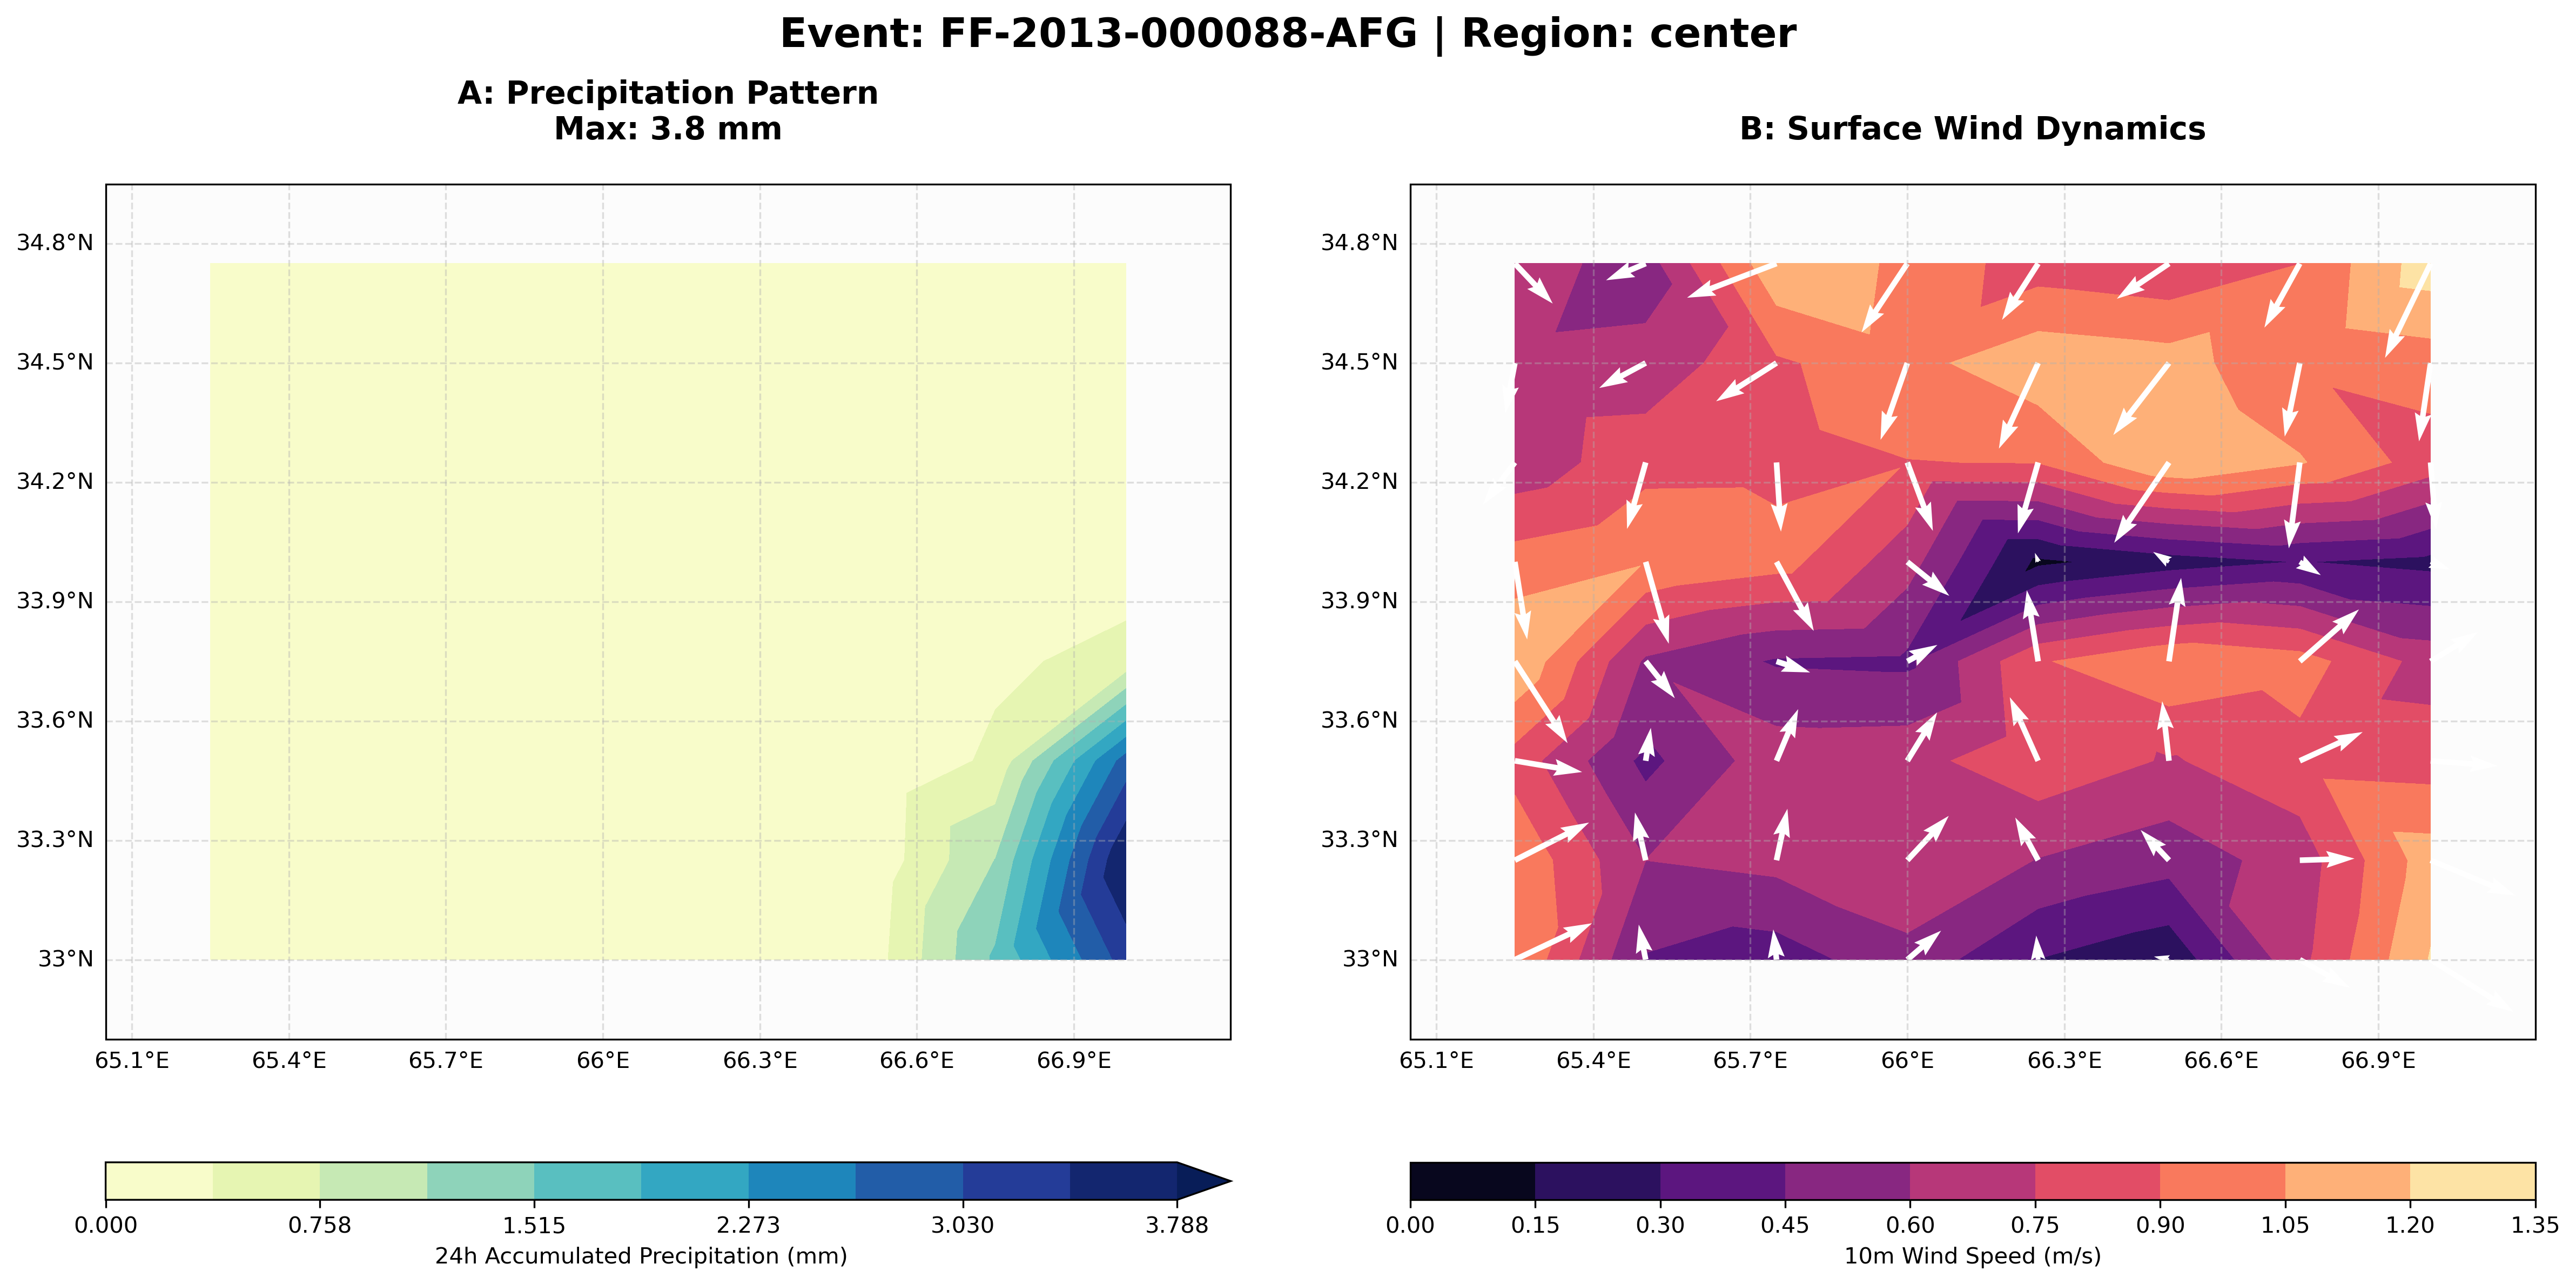

✅ Successfully saved: analysis_FF_2021_000098_MNG_Arkhangai.png


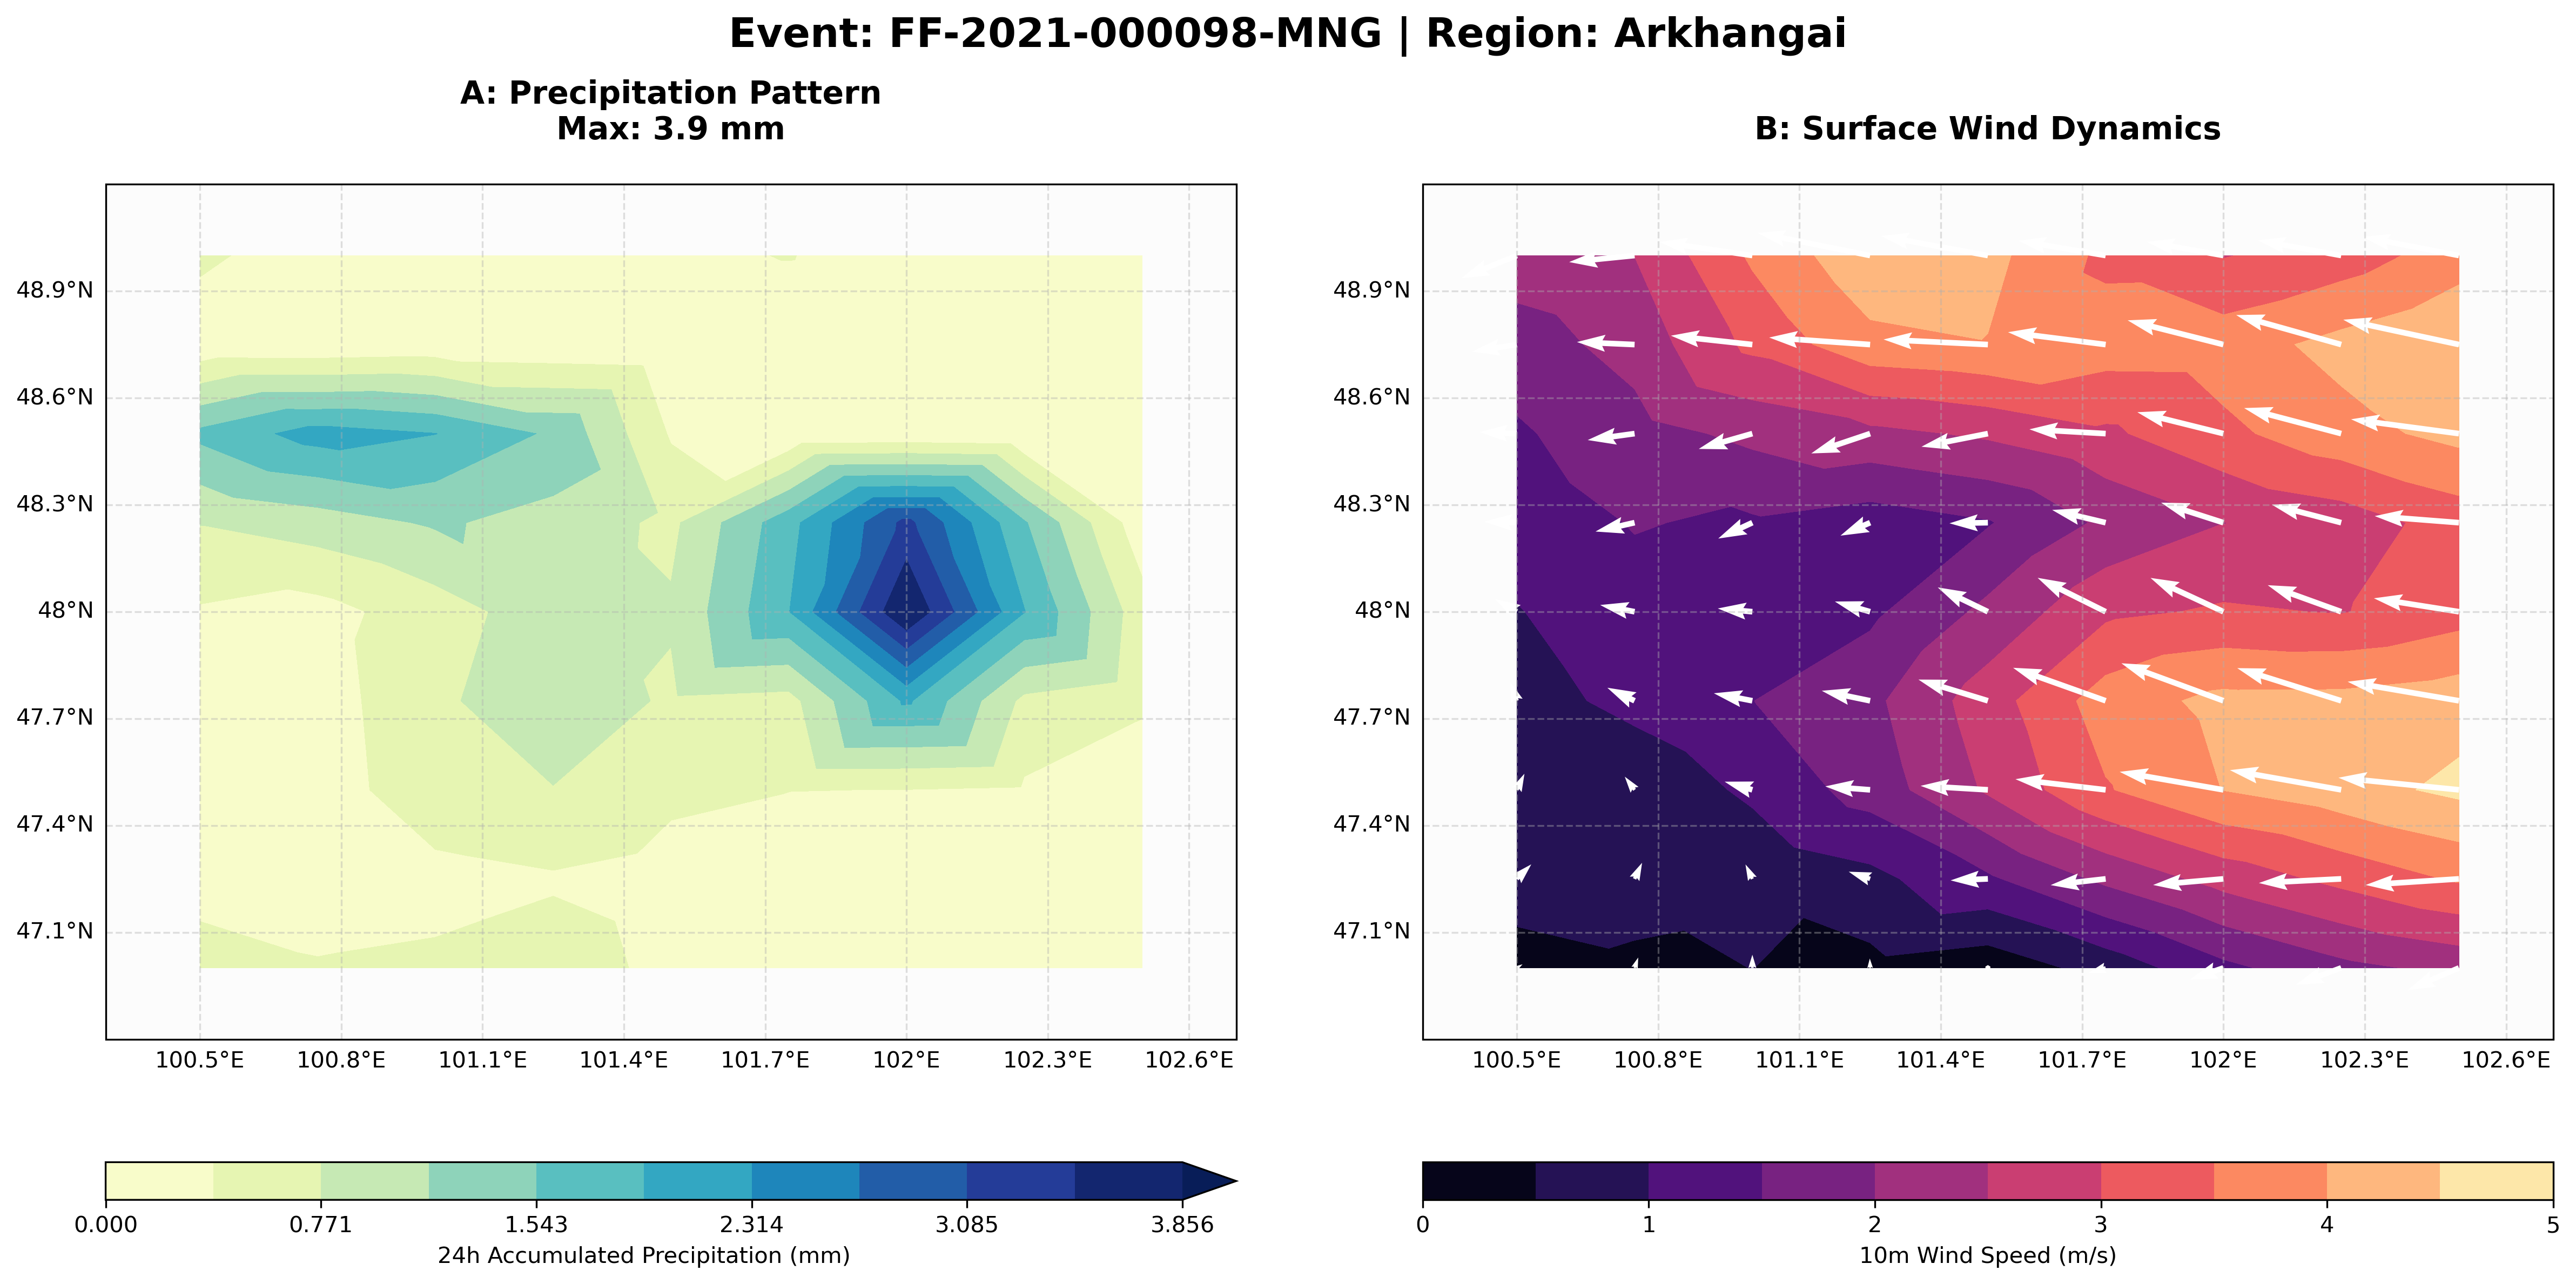

✅ Successfully saved: analysis_FF_2021_000090_SDN_center.png


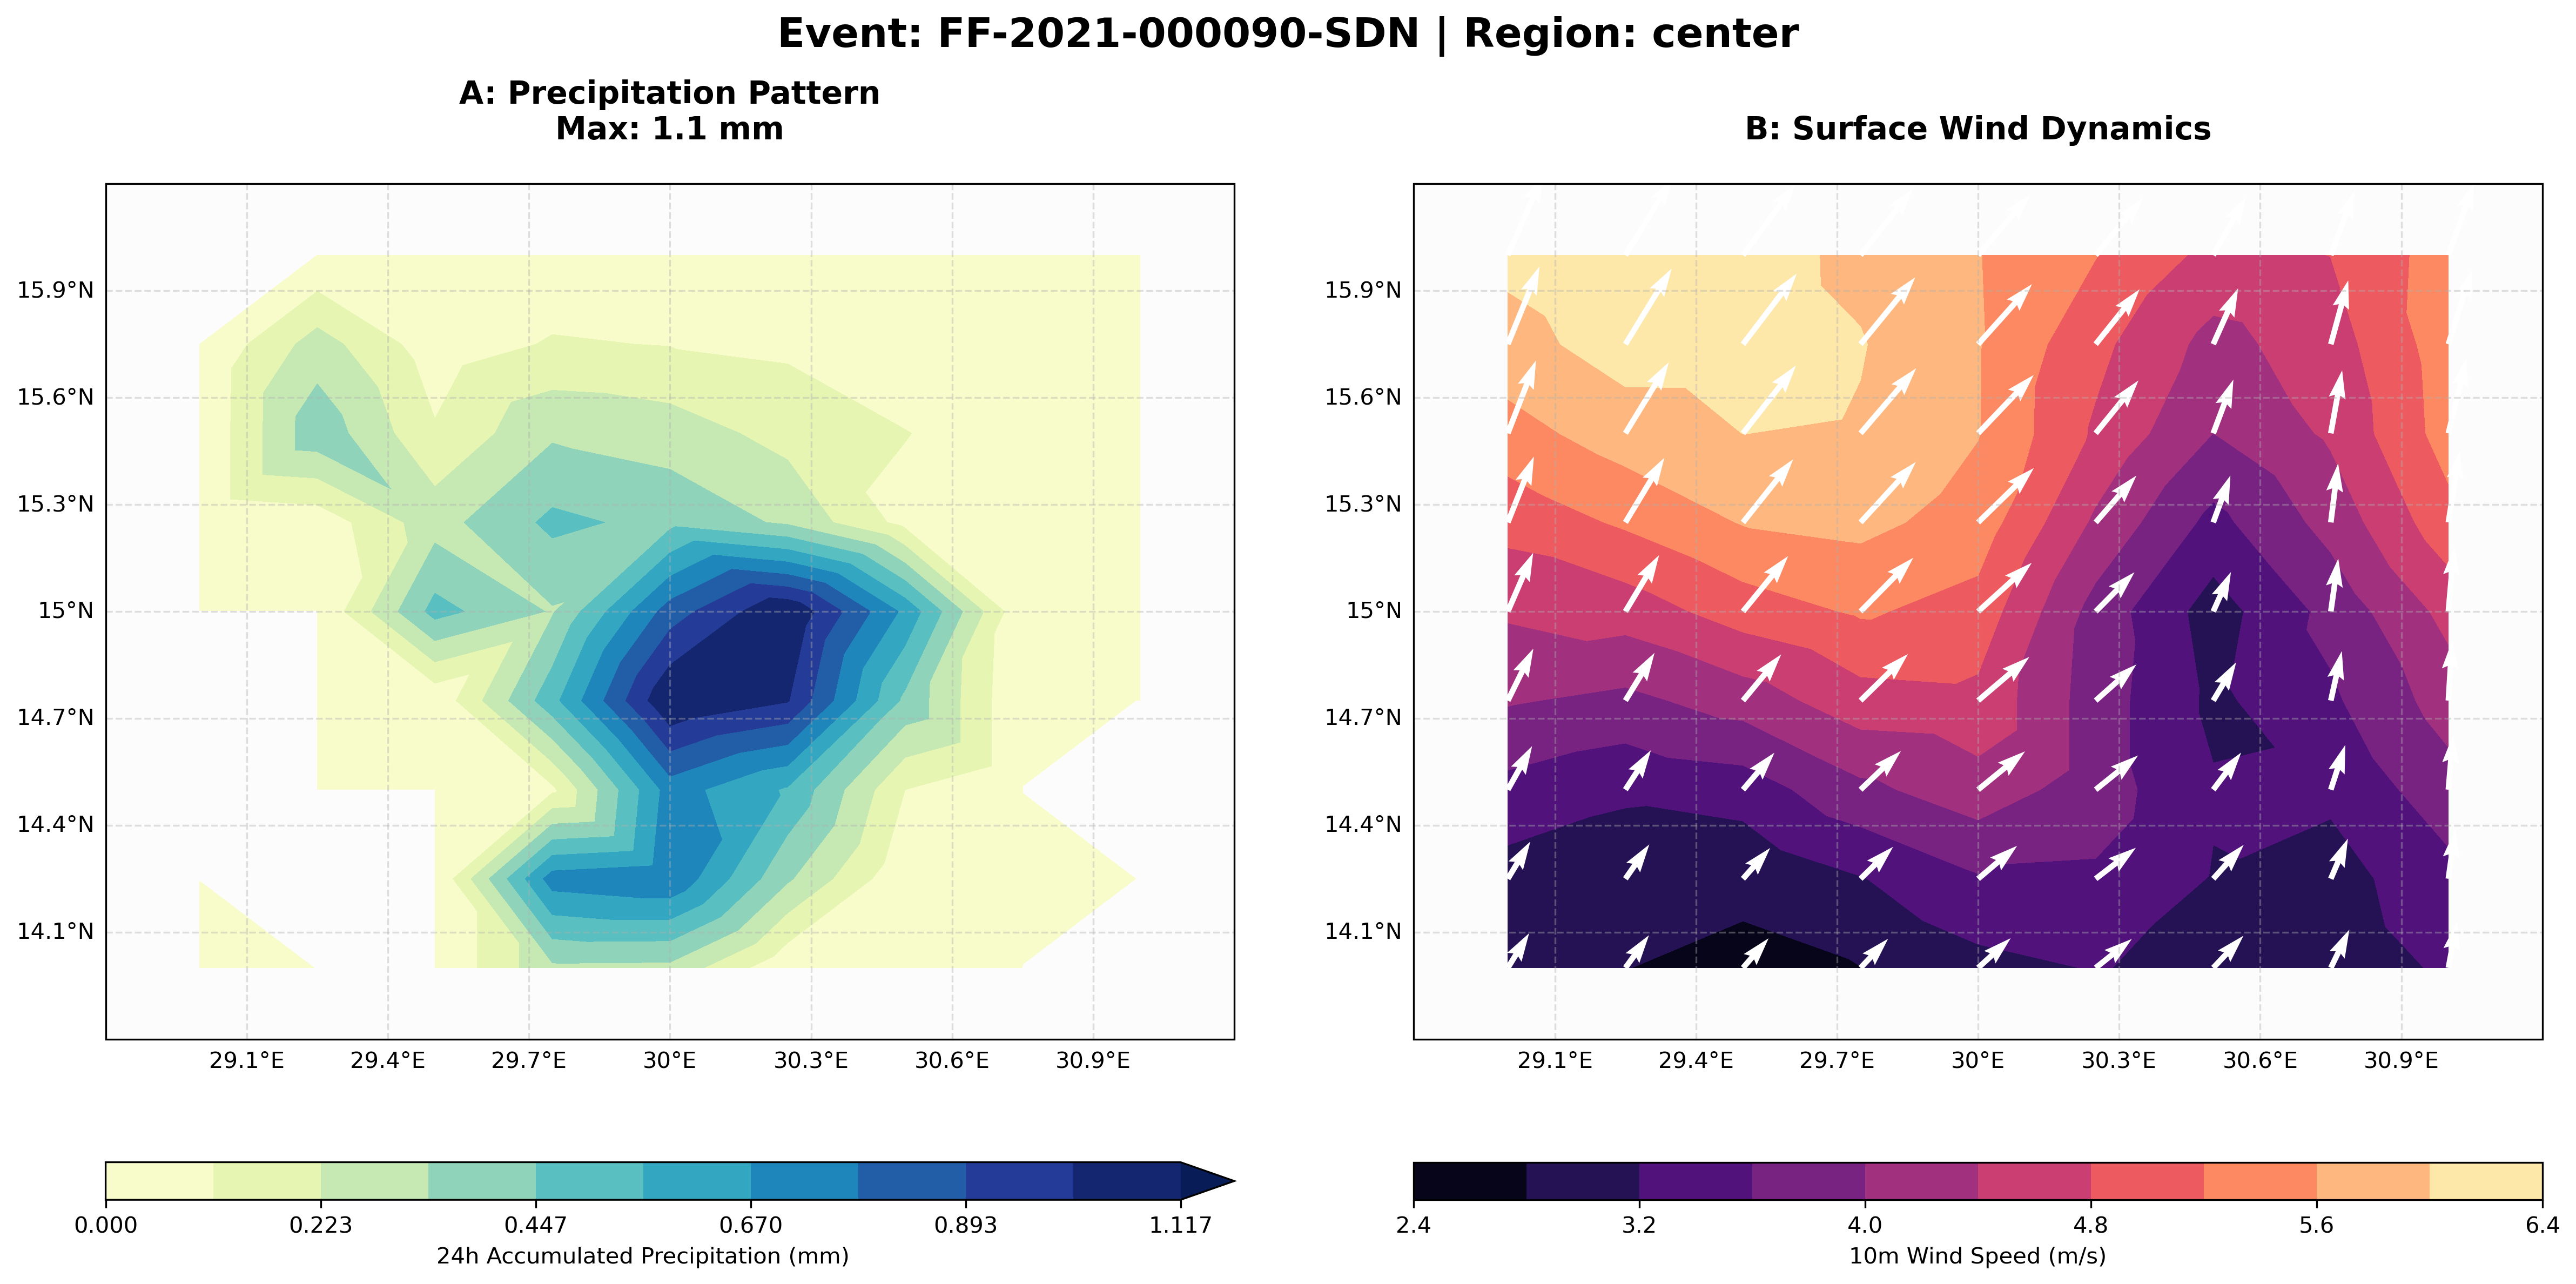

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.ticker as mticker

def visualize_era5_event(file_path):
    # 1. Load Data
    df = pd.read_csv(file_path)
    df_surface = df[df['level'] == 1000].copy()
    
    # --- AUTOMATIC COORDINATE CALCULATION ---
    # We add a small buffer (0.2 degrees) so the data isn't touching the edge
    lon_min, lon_max = df_surface['longitude'].min() - 0.2, df_surface['longitude'].max() + 0.2
    lat_min, lat_max = df_surface['latitude'].min() - 0.2, df_surface['latitude'].max() + 0.2
    auto_extent = [lon_min, lon_max, lat_min, lat_max]

    # --- AUTOMATIC COLOR SCALE CALCULATION ---
    max_precip = df_surface['precipitation_mm_24h'].max()
    # Create 10 linear steps from 0 to max precip for the colorbar
    precip_levels = np.linspace(0, max_precip, 11)

    # 2. Setup Figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), dpi=300, 
                                   subplot_kw={'projection': ccrs.PlateCarree()})

    def format_map(ax, title):
        ax.set_extent(auto_extent, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=1.5, zorder=3)
        ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.7, zorder=3)
        ax.add_feature(cfeature.LAND, facecolor='#fcfcfc')
        ax.set_aspect('auto') 
        
        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4, zorder=4)
        gl.top_labels = False
        gl.right_labels = False
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

    # --- Panel A: Precipitation ---
    format_map(ax1, f"A: Precipitation Pattern\nMax: {max_precip:.1f} mm")
    cf1 = ax1.tricontourf(df_surface['longitude'], df_surface['latitude'], 
                          df_surface['precipitation_mm_24h'],
                          levels=precip_levels, cmap='YlGnBu', extend='max')

    plt.colorbar(cf1, ax=ax1, orientation='horizontal', pad=0.12, fraction=0.046, aspect=30,
                 label='24h Accumulated Precipitation (mm)')

    # --- Panel B: Wind Field ---
    format_map(ax2, "B: Surface Wind Dynamics")
    wind_speed = np.sqrt(df_surface['u_component_of_wind']**2 + df_surface['v_component_of_wind']**2)
    
    cf2 = ax2.tricontourf(df_surface['longitude'], df_surface['latitude'], wind_speed,
                          cmap='magma', levels=10)

    # Automatic quiver scaling based on area size
    ax2.quiver(df_surface['longitude'].values, df_surface['latitude'].values,
               df_surface['u_component_of_wind'].values, df_surface['v_component_of_wind'].values,
               color='white', scale=None, width=0.005)

    plt.colorbar(cf2, ax=ax2, orientation='horizontal', pad=0.12, fraction=0.046, aspect=30,
                 label='10m Wind Speed (m/s)')

    # Title based on Event ID and Region Label in the CSV
    event_id = df['event_id'].iloc[0]
    region = df['region_label'].iloc[0]
    plt.suptitle(f"Event: {event_id} | Region: {region}", fontsize=18, fontweight='bold', y=0.98)
    
    plt.tight_layout(w_pad=4)
    
    # Save automatically using the region name
    save_name = f"analysis_{event_id}_{region}.png".replace("-", "_")
    plt.savefig(save_name, bbox_inches='tight')
    print(f"✅ Successfully saved: {save_name}")
    plt.show()

# --- HOW TO USE ---
# You can now just pass any file path to this function:
visualize_era5_event("/home/teoaivalis/floods_kg/reanalysis_data/era5_ground_truth/FF_2013_000088_AFG/center_ERA5_truth.csv")
visualize_era5_event("/home/teoaivalis/floods_kg/reanalysis_data/era5_ground_truth/FF_2021_000098_MNG/Arkhangai_ERA5_truth.csv")
visualize_era5_event("/home/teoaivalis/floods_kg/reanalysis_data/era5_ground_truth/FF_2021_000090_SDN/center_ERA5_truth.csv")

--- DATASET OVERVIEW ---
<xarray.Dataset> Size: 18kB
Dimensions:                  (latitude: 8, longitude: 8, level: 13)
Coordinates:
  * latitude                 (latitude) float32 32B 45.0 44.75 ... 43.5 43.25
  * longitude                (longitude) float32 32B 17.0 17.25 ... 18.5 18.75
  * level                    (level) int64 104B 1000 925 850 700 ... 150 100 50
    prediction_timedelta     timedelta64[ns] 8B ...
    time                     datetime64[ns] 8B ...
Data variables:
    mean_sea_level_pressure  (latitude, longitude) float32 256B ...
    10m_u_component_of_wind  (latitude, longitude) float32 256B ...
    10m_v_component_of_wind  (latitude, longitude) float32 256B ...
    2m_temperature           (latitude, longitude) float32 256B ...
    geopotential             (level, latitude, longitude) float32 3kB ...
    specific_humidity        (level, latitude, longitude) float32 3kB ...
    temperature              (level, latitude, longitude) float32 3kB ...
    u_component_

/tmp/ipykernel_1678359/1014428224.py:6: FutureWarning: In a future version, xarray will not decode the variable 'prediction_timedelta' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(nc_path)


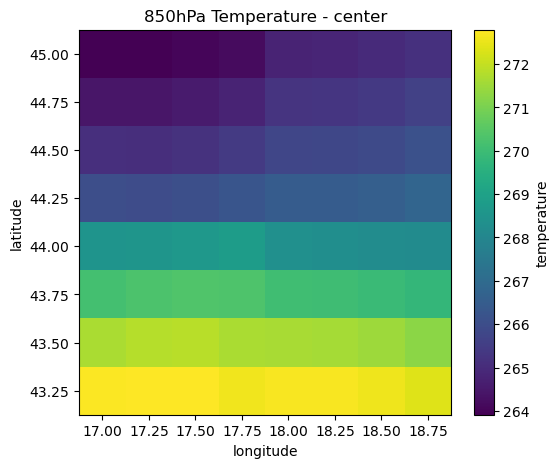

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

# 1. Load the file
nc_path = '/home/teoaivalis/floods_kg/reanalysis_data/new_pangu_predictions/FL_2022_000378_BIH/center_Pangu_data.nc'
ds = xr.open_dataset(nc_path)

# 2. Print the Structure
print("--- DATASET OVERVIEW ---")
print(ds)

print("\n--- DIMENSION CHECK ---")
# We expect: latitude: 8 or 9, longitude: 8 or 9, level: 13
print(f"Levels: {len(ds.level)} (Expected 13)")
print(f"Grid Size: {ds.latitude.size}x{ds.longitude.size} (Expected ~8x8)")

print("\n--- VARIABLE STATS ---")
# Check for NaNs and the range of Geopotential
for var in ds.data_vars:
    val_min = ds[var].min().values
    val_max = ds[var].max().values
    nan_count = ds[var].isnull().sum().values
    print(f"{var:25} | Min: {val_min:10.2f} | Max: {val_max:10.2f} | NaNs: {nan_count}")

# 3. Quick Visual: Temperature at 850hPa (Cloud level)
plt.figure(figsize=(6, 5))
ds['temperature'].sel(level=850).plot()
plt.title(f"850hPa Temperature - {ds.attrs.get('region_label', 'Event Area')}")
plt.show()

In [3]:
# Check if 'q' exists alongside 'specific_humidity'
print("Variables in Zarr:", list(ds.data_vars))
print("Max of specific_humidity:", ds.specific_humidity.max().values)

Variables in Zarr: ['mean_sea_level_pressure', '10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind']
Max of specific_humidity: 0.0048869345


In [9]:
import numpy as np
import os
from sklearn.metrics.pairwise import cosine_similarity

# Path to your new signatures
sig_dir = '/home/teoaivalis/floods_kg/reanalysis_data/event_embeddings'
files = [f for f in os.listdir(sig_dir) if f.endswith('.npy')]

print(f"--- ANALYZING {len(files)} SIGNATURES ---")

# 1. Numerical Sanity Check
all_sigs = []
for f in files[:10]: # Check the first 10 for stats
    sig = np.load(os.path.join(sig_dir, f))
    all_sigs.append(sig)
    
    has_nan = np.isnan(sig).any()
    v_min, v_max = sig.min(), sig.max()
    v_mean, v_std = sig.mean(), sig.std()
    
    print(f"File: {f[:30]}...")
    print(f"  NaNs: {has_nan} | Range: [{v_min:.3f}, {v_max:.3f}] | Mean: {v_mean:.3f} | Std: {v_std:.3f}")

# 2. Semantic Similarity Check (The 'Common Sense' Test)
if len(all_sigs) >= 2:
    print("\n--- SIMILARITY TEST ---")
    # Let's compare the first two signatures in the folder
    # Ideally, pick two from the same Event ID if possible
    sim = cosine_similarity(all_sigs[0].reshape(1, -1), all_sigs[1].reshape(1, -1))[0][0]
    
    print(f"Comparing {files[0]} vs {files[1]}")
    print(f"  Cosine Similarity: {sim:.4f}")
    
    if sim > 0.99:
        print("  Status: [CAUTION] Signatures are nearly identical. Might be capturing too much global background noise.")
    elif sim > 0.70:
        print("  Status: [GOOD] Signatures are related but distinct.")
    else:
        print("  Status: [DIVERSE] Signatures are very different. Good for distinguishing events.")

--- ANALYZING 1 SIGNATURES ---
File: FF_2022_000278_MNG_Chingeltei_...
  NaNs: False | Range: [0.029, 0.029] | Mean: 0.029 | Std: 0.000


In [14]:
!pip install microsoft-aurora
!pip install timm einops

In [18]:
!pip install --upgrade timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 15.7 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: timm
    Found existing installation: timm 0.6.13
    Uninstalling timm-0.6.13:
      Successfully uninstalled timm-0.6.13


In [19]:
import timm
print(timm.__version__)
# It should ideally be 0.9.0 or higher

0.6.13


In [22]:
from datetime import datetime

import torch

from aurora import AuroraSmallPretrained, Batch, Metadata

model = AuroraSmallPretrained()
model.load_checkpoint()

batch = Batch(
    surf_vars={k: torch.randn(1, 2, 17, 32) for k in ("2t", "10u", "10v", "msl")},
    static_vars={k: torch.randn(17, 32) for k in ("lsm", "z", "slt")},
    atmos_vars={k: torch.randn(1, 2, 4, 17, 32) for k in ("z", "u", "v", "t", "q")},
    metadata=Metadata(
        lat=torch.linspace(90, -90, 17),
        lon=torch.linspace(0, 360, 32 + 1)[:-1],
        time=(datetime(2020, 6, 1, 12, 0),),
        atmos_levels=(100, 250, 500, 850),
    ),
)

prediction = model.forward(batch)

print(prediction.surf_vars["2t"])

tensor([[[[20.5971, 18.9325, 15.7143, 16.1067, 20.0627, 18.8521, 15.7003,
           16.5990, 20.5428, 18.9334, 15.6813, 16.0182, 20.5919, 19.0307,
           15.6738, 16.5017, 20.8755, 19.4657, 16.3960, 17.0123, 20.3276,
           19.2189, 16.0316, 16.6889, 20.6769, 19.3529, 16.5115, 17.1692,
           21.8377, 20.2455, 16.9045, 17.4542],
          [17.3604, 18.0651, 23.2966, 19.0399, 17.1407, 17.8958, 23.0666,
           18.9483, 17.3099, 17.8656, 22.7355, 18.2971, 17.4564, 18.2544,
           23.2976, 19.0763, 17.4189, 18.0742, 23.1504, 19.0963, 17.1342,
           18.2183, 23.4204, 19.0980, 17.6772, 18.5722, 23.8084, 19.4554,
           18.4856, 18.9694, 23.8278, 19.4639],
          [15.8665, 18.3780, 22.6338, 23.0357, 15.2623, 17.7750, 22.0536,
           22.5710, 15.6526, 17.9503, 21.7012, 22.0461, 14.8854, 17.6318,
           22.1349, 22.3859, 15.5499, 17.8882, 22.0167, 22.5508, 14.8844,
           17.8214, 22.4044, 22.7241, 15.9492, 18.5097, 22.8246, 22.9847,
           16.29

In [24]:
from datetime import datetime

import torch

from aurora import AuroraSmallPretrained, Batch, Metadata

model = AuroraSmallPretrained()
model.load_checkpoint()

# Use the batch you just created in the previous step
with torch.no_grad():
    # 1. Normalise (Crucial for the Foundation Model's brain)
    normalized_batch = batch.normalise(model.surf_stats)
    
    # 2. Lead Time (0.0 means 'representation of the current state')
    device = next(model.parameters()).device
    lead_time = torch.tensor([0.0], dtype=torch.float32).to(device)

    # 3. Step 1: The Encoder (Pixels -> Latent Tokens)
    # Tapping the internal 'model' attribute within the wrapper
    latent_tokens = model.model.encoder(normalized_batch, lead_time)

    # 4. Step 2: The Backbone (The 'Reasoning' Stage)
    # This is where the foundation-level knowledge lives
    knowledge_state = model.model.backbone(latent_tokens)

# 5. Collapse into a 1D Vector (The Signature)
# knowledge_state shape is [Batch, Tokens, Channels]
# We average across the tokens to get a global fingerprint
signature = torch.mean(knowledge_state, dim=1).squeeze().cpu().numpy()

print("--- FOUNDATION KNOWLEDGE SIGNATURE ---")
print(f"Vector Length: {len(signature)}")
print(f"First 5 values: {signature[:5]}")
print(f"Vector Variance: {signature.var():.4f}")

AttributeError: 'AuroraSmallPretrained' object has no attribute 'model'